In [4]:
# 导入必要的库
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve, classification_report, roc_auc_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import lightgbm as lgb
from lightgbm import LGBMClassifier, LGBMRegressor

# 设置matplotlib为inline模式，方便在Jupyter Notebook中显示图形
%matplotlib inline

# 设置中文字体
plt.rcParams['font.sans-serif'] = ['SimHei']  # 'SimHei' 是黑体
# 解决负号 '-' 显示为方框的问题
plt.rcParams['axes.unicode_minus'] = False

In [2]:
# ------------------------------------------------------------------------------
# 1. 数据加载和预处理
# ------------------------------------------------------------------------------

# 读入数据
# 该数据集来源: https://www.kaggle.com/datasets/davinwijaya/customer-retention
# 注意：请确保你的数据路径正确
data = pd.read_csv("F:\\AAAAAAAAAAAAAAAAAAAAA\\Senior\\subject\\数据挖掘\\实验十(2)\\data.csv")
data.head()

# 查看数据的基本信息，了解各列的数据类型和缺失情况
data.info()
data.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64000 entries, 0 to 63999
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   recency        64000 non-null  int64  
 1   history        64000 non-null  float64
 2   used_discount  64000 non-null  int64  
 3   used_bogo      64000 non-null  int64  
 4   zip_code       64000 non-null  object 
 5   is_referral    64000 non-null  int64  
 6   channel        64000 non-null  object 
 7   offer          64000 non-null  object 
 8   conversion     64000 non-null  int64  
dtypes: float64(1), int64(5), object(3)
memory usage: 4.4+ MB


,recency,history,used_discount,used_bogo,is_referral,conversion
count,64000.000000,64000.000000,64000.000000,64000.000000,64000.000000,64000.000000
mean,5.763734,242.085656,0.551031,0.549719,0.502250,0.146781
std,3.507592,256.158608,0.497393,0.497526,0.499999,0.353890
min,1.000000,29.990000,0.000000,0.000000,0.000000,0.000000
25%,2.000000,64.660000,0.000000,0.000000,0.000000,0.000000
50%,6.000000,158.110000,1.000000,1.000000,1.000000,0.000000
75%,9.000000,325.657500,1.000000,1.000000,1.000000,0.000000
max,12.000000,3345.930000,1.000000,1.000000,1.000000,1.000000


--- 离散变量取值分布 ---

used_discount:
used_discount
1    35266
0    28734
Name: count, dtype: int64

used_bogo:
used_bogo
1    35182
0    28818
Name: count, dtype: int64

zip_code:
zip_code
Surburban    28776
Urban        25661
Rural         9563
Name: count, dtype: int64

is_referral:
is_referral
1    32144
0    31856
Name: count, dtype: int64

channel:
channel
Web             28217
Phone           28021
Multichannel     7762
Name: count, dtype: int64

offer:
offer
Buy One Get One    21387
Discount           21307
No Offer           21306
Name: count, dtype: int64

conversion:
conversion
0    54606
1     9394
Name: count, dtype: int64


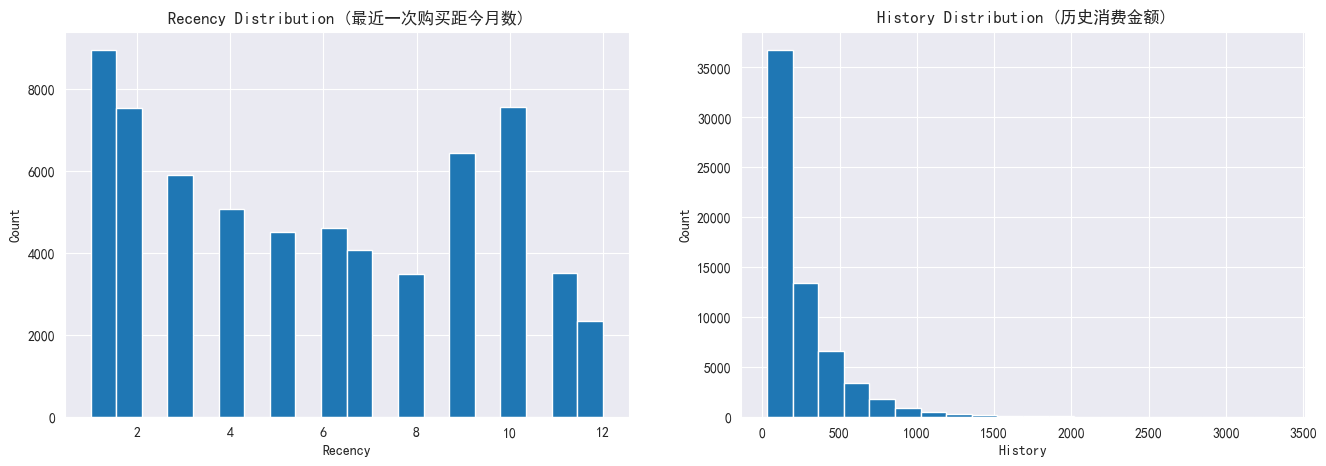

In [5]:
# ------------------------------------------------------------------------------
# 2. 探索性数据分析 (EDA)
# ------------------------------------------------------------------------------

# 查看离散变量及其取值分布
print("--- 离散变量取值分布 ---")
for column in data.drop(columns=['recency', 'history']):
    print(f"\n{column}:")
    print(data[column].value_counts())

# 查看连续变量的分布
con_columns = ['recency', 'history']

fig = plt.figure(figsize=(16, 5))
ax1 = fig.add_subplot(121)
data['recency'].hist(ax=ax1, bins=20)
ax1.set_title('Recency Distribution (最近一次购买距今月数)')
ax1.set_xlabel('Recency')
ax1.set_ylabel('Count')

ax2 = fig.add_subplot(122)
data['history'].hist(ax=ax2, bins=20)
ax2.set_title('History Distribution (历史消费金额)')
ax2.set_xlabel('History')
ax2.set_ylabel('Count')
plt.show()

In [6]:
# ------------------------------------------------------------------------------
# 3. 数据准备和初步分析
# ------------------------------------------------------------------------------

# 目标变量及干预变量列名修改，使其更符合因果推断的标准命名习惯
df_model = data.rename(columns={'conversion': 'target'})  # 目标变量，是否转化
df_model = df_model.rename(columns={'offer': 'treatment'})  # 干预变量，是否接受优惠

# 将干预变量进行数值编码
# 'No Offer' (无优惠) -> 0 (对照组)
# 'Buy One Get One' (买一送一) -> -1 (干预组A)
# 'Discount' (折扣) -> 1 (干预组B)
# 这里我们主要关注 'Buy One Get One' 这个干预
df_model.treatment = df_model.treatment.map({'No Offer': 0, 'Buy One Get One': -1, 'Discount': 1})

# 将离散特征转换为哑变量（独热编码）
df_model = pd.get_dummies(df_model)
print("\n--- 处理后的数据结构 ---")
df_model.head()

# 计算不同干预条件下的平均转化率
print("\n--- 不同干预水平下的平均转化率 ---")
conversion_rates = df_model.groupby('treatment').agg({'target': ['mean', 'count']})
conversion_rates.columns = ['转化率', '用户数']
print(conversion_rates)



--- 处理后的数据结构 ---

--- 不同干预水平下的平均转化率 ---
                转化率    用户数
treatment                 
-1         0.151400  21387
 0         0.106167  21306
 1         0.182757  21307



--- Recency不同区间下的Uplift分析 ---
              group_proportion  control_cr  treatment_cr    uplift  \
recency_bins                                                         
(0.999, 2.0]          0.257255    0.141948      0.188469  0.046521   
(2.0, 4.0]            0.171761    0.119223      0.153428  0.034204   
(4.0, 7.0]            0.208325    0.101706      0.148198  0.046492   
(7.0, 10.0]           0.271379    0.075165      0.122849  0.047685   
(10.0, 12.0]          0.091280    0.082335      0.135996  0.053661   

              uplift_percent  
recency_bins                  
(0.999, 2.0]           32.77  
(2.0, 4.0]             28.69  
(4.0, 7.0]             45.71  
(7.0, 10.0]            63.44  
(10.0, 12.0]           65.17  


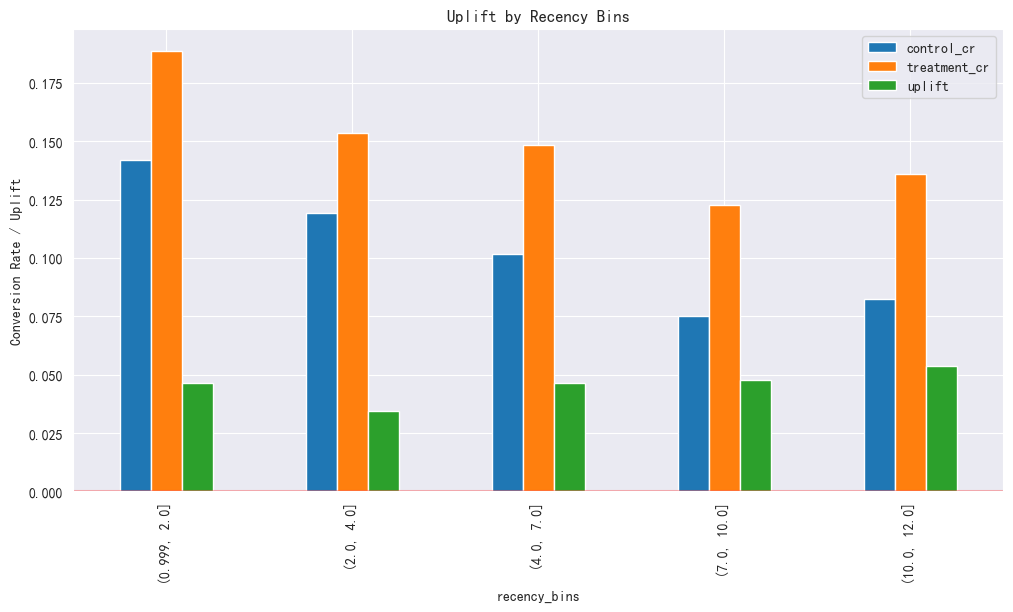

In [9]:
# ------------------------------------------------------------------------------
# 4. 手动Uplift分析：探索单特征下的增益
# ------------------------------------------------------------------------------

# 定义一个函数，用于计算在某个维度(dim)上，干预组相对于对照组的转化率提升
def get_every_group_up(data, dim, treatment_col, target_col):
    """
    计算在某个特征的不同分组下，干预组相对对照组的转化率提升。

    参数:
    data (pd.DataFrame): 包含特征、干预和目标变量的数据框。
    dim (str): 用于分组的特征名称。
    treatment_col (str): 干预变量名称 (0表示对照, -1表示干预)。
    target_col (str): 目标变量名称。

    返回:
    pd.DataFrame: 包含各组占比、转化率和提升值的结果。
    """
    # 按特征和干预状态分组，计算转化数和用户数
    # 添加 observed=True 以采用未来的默认行为并消除警告
    grouped = data.groupby(by=[dim, treatment_col], observed=True).agg({
        target_col: 'sum',
        'treatment': 'count'  # 用'treatment'列计数，因为它不为空
    }).rename(columns={target_col: 'target_sum', 'treatment': 'user_count'})

    # 计算转化率
    grouped['conversion_rate'] = grouped['target_sum'] / grouped['user_count']

    # 分别提取对照组和干预组的数据
    # .loc[(slice(None), 0), ...] 表示所有dim值，且treatment为0
    control = grouped.loc[(slice(None), 0), 'conversion_rate'].reset_index(level=1, drop=True)
    treatment = grouped.loc[(slice(None), -1), 'conversion_rate'].reset_index(level=1, drop=True)

    # 计算各分组的用户占比
    group_distribution = data[dim].value_counts(normalize=True).sort_index()

    # 合并结果
    result_df = pd.DataFrame({
        'group_proportion': group_distribution,
        'control_cr': control,
        'treatment_cr': treatment
    }).fillna(0) # 填充可能因分组不存在而产生的NaN

    # 计算 uplift
    result_df['uplift'] = result_df['treatment_cr'] - result_df['control_cr']
    result_df['uplift_percent'] = (result_df['uplift'] / result_df['control_cr'] * 100).round(2)

    return result_df

# 筛选出我们关注的干预组('Buy One Get One', 编码为-1)和对照组(编码为0)
# 使用 .copy() 明确创建副本，避免 SettingWithCopyWarning
uplift_data = df_model[df_model['treatment'].isin([-1, 0])].copy()

# 现在再进行赋值操作就不会有警告了
uplift_data['recency_bins'], bins = pd.qcut(uplift_data['recency'], q=5, retbins=True, duplicates='drop')
# 正确调用，传入4个参数
diff_recency_bins_df = get_every_group_up(uplift_data, 'recency_bins', 'treatment', 'target')

# 对 'recency' 进行分箱，然后查看不同区间下的 uplift
uplift_data['recency_bins'], bins = pd.qcut(uplift_data['recency'], q=5, retbins=True, duplicates='drop')
print("\n--- Recency不同区间下的Uplift分析 ---")
diff_recency_bins_df = get_every_group_up(uplift_data, 'recency_bins', 'treatment', 'target')
print(diff_recency_bins_df)
diff_recency_bins_df[['control_cr', 'treatment_cr', 'uplift']].plot(kind='bar', figsize=(12, 6))
plt.title('Uplift by Recency Bins')
plt.ylabel('Conversion Rate / Uplift')
plt.axhline(y=0, color='r', linestyle='-', alpha=0.3)
plt.show()

In [10]:
# ------------------------------------------------------------------------------
# 5. 建模与评估工具函数
# ------------------------------------------------------------------------------

# 定义一个函数，用于绘制模型的ROC曲线、找到最佳阈值并输出分类报告
def plot_model_result(preds_proba, y_true):
    """
    绘制二分类模型的ROC曲线，并输出基于最佳阈值(Youden's J statistic)的分类报告。

    参数:
    preds_proba (array-like): 模型预测的正类概率。
    y_true (array-like): 真实的标签。
    """
    # 计算ROC曲线的假正率(FPR)、召回率(Recall)和阈值(Thresholds)
    fpr, tpr, thresholds = roc_curve(y_true, preds_proba, pos_label=1)
    # 计算AUC值
    auc = roc_auc_score(y_true, preds_proba)

    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color='red', lw=2, label=f'ROC curve (AUC = {auc:.4f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Guess')

    # 找到最佳阈值点 (Youden's J = TPR - FPR)
    j_scores = tpr - fpr
    best_idx = np.argmax(j_scores)
    best_threshold = thresholds[best_idx]

    plt.scatter(fpr[best_idx], tpr[best_idx], color='black', s=100,
                label=f'Best Threshold ({best_threshold:.4f})')

    plt.xlim([-0.05, 1.05])
    plt.ylim([-0.05, 1.05])
    plt.xlabel('False Positive Rate (FPR)')
    plt.ylabel('True Positive Rate (TPR) / Recall')
    plt.title('Receiver Operating Characteristic (ROC) Curve')
    plt.legend(loc="lower right")
    plt.show()

    # 根据最佳阈值进行预测
    y_pred = (preds_proba > best_threshold).astype(int)

    print("\n--- Classification Report ---")
    print(classification_report(y_true, y_pred, digits=4))

In [11]:
# ------------------------------------------------------------------------------
# 6. 因果推断模型：T-Learner
# ------------------------------------------------------------------------------
print("\n" + "="*50)
print("T-Learner Model")
print("="*50)

# 准备特征 (X), 干预 (T), 和目标 (y)
# 注意：这里的T和y是从整个数据集df_model中提取的，用于后续的模型评估
T = 'treatment'
y = 'target'
# 特征是除了目标变量和干预变量之外的所有列
X = df_model.columns.difference([T, y])

# 划分训练集和测试集
# 这是一个标准的hold-out验证方法
train_df, test_df = train_test_split(df_model, test_size=0.2, random_state=123)

# 步骤 1: 在训练集上分别训练两个模型
# m0: 在对照组 (T=0) 上训练的模型，用于预测潜在结果 Y(0)
# m1: 在干预组 (T=-1) 上训练的模型，用于预测潜在结果 Y(1)
# 注意：这里使用LGBMClassifier，因为目标是二分类问题
m0 = LGBMClassifier(max_depth=2, min_child_samples=60, random_state=123)
m1 = LGBMClassifier(max_depth=2, min_child_samples=60, random_state=123)

# 在对照组数据上训练m0
m0.fit(train_df.query(f"{T}==0")[X], train_df.query(f"{T}==0")[y])
# 在干预组数据上训练m1
m1.fit(train_df.query(f"{T}==-1")[X], train_df.query(f"{T}==-1")[y])

# 步骤 2: 估计CATE (Conditional Average Treatment Effect)
# CATE_i = E[Y(1)_i - Y(0)_i | X_i]
# 对于每个样本，用m1的预测减去m0的预测来估计其ITE
t_learner_cate_train = m1.predict_proba(train_df[X])[:, 1] - m0.predict_proba(train_df[X])[:, 1]
t_learner_cate_test = m1.predict_proba(test_df[X])[:, 1] - m0.predict_proba(test_df[X])[:, 1]

# 将预测的CATE添加到数据框中，方便后续评估
train_df['t_learner_cate'] = t_learner_cate_train
test_df['t_learner_cate'] = t_learner_cate_test



T-Learner Model
[LightGBM] [Info] Number of positive: 1817, number of negative: 15210
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000567 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 286
[LightGBM] [Info] Number of data points in the train set: 17027, number of used features: 11
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.106713 -> initscore=-2.124766
[LightGBM] [Info] Start training from score -2.124766
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive

[LightGBM] [Info] Number of positive: 1817, number of negative: 15210
- 这表示当前训练的数据集包含 1817 个正样本（标签为 1）和 15210 个负样本（标签为 0）。
- 正样本比例：1817 / (1817 + 15210) ≈ 10.67%。

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000567 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.

- LightGBM 自动选择了 按行并行（row-wise multi-threading）的方式进行训练，这是一种优化手段。
- 如果想避免自动选择的开销，可以手动设置 force_row_wise=true。
- 如果内存不足，可以尝试设置 force_col_wise=true，按列并行。

[LightGBM] [Info] Total Bins 286
- 数据集中所有特征的总分箱数为 286。LightGBM 会将连续特征分成多个区间（bin）来加速训练。

[LightGBM] [Info] Number of data points in the train set: 17027, number of used features: 11
- 训练集样本数：17027。
- 使用的特征数：11。

[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.106713 -> initscore=-2.124766
- 对于二分类问题，LightGBM 会根据正负样本比例初始化分数。
- pavg 是正样本比例（10.67%），initscore 是初始分数（-2.124766）。

[LightGBM] [Info] Start training from score -2.124766
- 模型开始从初始分数进行训练。

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
- 表示在当前的树中，没有找到能进一步提升模型性能的分裂点。
- **原因：**
- 可能是树的深度已经达到了限制（max_depth=2）。
- 也可能是当前节点的样本数已经少于 min_child_samples（60），无法继续分裂。
- 或者是所有可能的分裂点都不能带来正的增益（即无法降低损失函数）。
- 影响：这会导致树的生长提前停止。如果模型欠拟合，可以适当调整参数。

In [12]:
# ------------------------------------------------------------------------------
# 6. 因果推断模型：T-Learner
# ------------------------------------------------------------------------------
print("\n" + "="*50)
print("T-Learner Model")
print("="*50)

# 准备特征 (X), 干预 (T), 和目标 (y)
# 注意：这里的T和y是从整个数据集df_model中提取的，用于后续的模型评估
T = 'treatment'
y = 'target'
# 特征是除了目标变量和干预变量之外的所有列
X = df_model.columns.difference([T, y])

# 划分训练集和测试集
# 这是一个标准的hold-out验证方法
train_df, test_df = train_test_split(df_model, test_size=0.2, random_state=123)

# 步骤 1: 在训练集上分别训练两个模型
# m0: 在对照组 (T=0) 上训练的模型，用于预测潜在结果 Y(0)
# m1: 在干预组 (T=-1) 上训练的模型，用于预测潜在结果 Y(1)
# 注意：这里使用LGBMClassifier，因为目标是二分类问题
m0 = LGBMClassifier(max_depth=2, min_child_samples=60, random_state=123)
m1 = LGBMClassifier(max_depth=2, min_child_samples=60, random_state=123)

# 在对照组数据上训练m0
m0.fit(train_df.query(f"{T}==0")[X], train_df.query(f"{T}==0")[y])
# 在干预组数据上训练m1
m1.fit(train_df.query(f"{T}==-1")[X], train_df.query(f"{T}==-1")[y])

# 步骤 2: 估计CATE (Conditional Average Treatment Effect)
# CATE_i = E[Y(1)_i - Y(0)_i | X_i]
# 对于每个样本，用m1的预测减去m0的预测来估计其ITE
t_learner_cate_train = m1.predict_proba(train_df[X])[:, 1] - m0.predict_proba(train_df[X])[:, 1]
t_learner_cate_test = m1.predict_proba(test_df[X])[:, 1] - m0.predict_proba(test_df[X])[:, 1]

# 将预测的CATE添加到数据框中，方便后续评估
train_df['t_learner_cate'] = t_learner_cate_train
test_df['t_learner_cate'] = t_learner_cate_test



T-Learner Model
[LightGBM] [Info] Number of positive: 1817, number of negative: 15210
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000288 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 286
[LightGBM] [Info] Number of data points in the train set: 17027, number of used features: 11
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.106713 -> initscore=-2.124766
[LightGBM] [Info] Start training from score -2.124766
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive

In [15]:
# ------------------------------------------------------------------------------
# 7. 因果推断模型：X-Learner
# ------------------------------------------------------------------------------
print("\n" + "="*50)
print("X-Learner Model")
print("="*50)

# 步骤 1: 第一阶段 - 训练两个基础模型 (与T-Learner相同)
# m0: 预测 Y(0)
# m1: 预测 Y(1)
m0_x = LGBMClassifier(max_depth=2, min_child_samples=30, random_state=123)
m1_x = LGBMClassifier(max_depth=2, min_child_samples=30, random_state=123)

m0_x.fit(train_df.query(f"{T}==0")[X], train_df.query(f"{T}==0")[y])
m1_x.fit(train_df.query(f"{T}==-1")[X], train_df.query(f"{T}==-1")[y])

# 步骤 2: 为每个样本计算"伪结果" (Pseudo-outcomes)
# 对于对照组样本 (T=0)，其伪结果 d = Y(1)_pred - Y_obs
# 对于干预组样本 (T=-1)，其伪结果 d = Y_obs - Y(0)_pred
d_train = np.where(
    train_df[T] == 0,
    m1_x.predict_proba(train_df[X])[:, 1] - train_df[y],  # 对照组: 预测的干预效应 - 实际的对照结果
    train_df[y] - m0_x.predict_proba(train_df[X])[:, 1]   # 干预组: 实际的干预结果 - 预测的对照结果
)

# 步骤 3: 第二阶段 - 训练两个元模型 (Meta-models)
# mx0: 在对照组样本上，以伪结果d为目标进行训练，用于预测 E[Y(1)-Y(0) | T=0, X]
# mx1: 在干预组样本上，以伪结果d为目标进行训练，用于预测 E[Y(1)-Y(0) | T=1, X]
mx0 = LGBMRegressor(max_depth=2, min_child_samples=30, random_state=123)
mx1 = LGBMRegressor(max_depth=2, min_child_samples=30, random_state=123)

mx0.fit(train_df.query(f"{T}==0")[X], d_train[train_df[T] == 0])
mx1.fit(train_df.query(f"{T}==-1")[X], d_train[train_df[T] == -1])

# 步骤 4: 训练倾向得分模型 (Propensity Score Model)
# 倾向得分 e(X) = P(T=1 | X)，即给定特征X，样本接受干预的概率
# 这里我们预测的是 T=-1 的概率
g = LogisticRegression(solver="lbfgs", penalty=None, max_iter=1000)
g.fit(train_df[X], (train_df[T] == -1).astype(int)) # 将T=-1转换为1，其他为0




X-Learner Model
[LightGBM] [Info] Number of positive: 1817, number of negative: 15210
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000472 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 286
[LightGBM] [Info] Number of data points in the train set: 17027, number of used features: 11
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.106713 -> initscore=-2.124766
[LightGBM] [Info] Start training from score -2.124766
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive

,penalty,None
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [16]:
# 定义一个函数来预测倾向得分
def predict_propensity_score(df, model, X_features):
    # 预测干预(T=-1)的概率
    return model.predict_proba(df[X_features])[:, 1]

# 步骤 5: 组合结果得到最终的CATE估计
# e_i 是样本i接受干预的倾向得分
# X-Learner的CATE估计是一个加权平均:
# CATE_i = e_i * mx0(X_i) + (1 - e_i) * mx1(X_i)
e_train = predict_propensity_score(train_df, g, X)
x_learner_cate_train = e_train * mx0.predict(train_df[X]) + (1 - e_train) * mx1.predict(train_df[X])

e_test = predict_propensity_score(test_df, g, X)
x_learner_cate_test = e_test * mx0.predict(test_df[X]) + (1 - e_test) * mx1.predict(test_df[X])

# 将X-Learner预测的CATE添加到数据框中
train_df['x_learner_cate'] = x_learner_cate_train
test_df['x_learner_cate'] = x_learner_cate_test

In [17]:
# ------------------------------------------------------------------------------
# 8. 模型评估：增益曲线 (Gain Curve) 和 AUUC
# ------------------------------------------------------------------------------

# 定义一个函数来计算累积增益曲线的数据点
def cumulative_gain_curve(df, cate_col, treatment_col, target_col, treatment_value=-1):
    """
    计算并返回增益曲线的数据点。

    参数:
    df (pd.DataFrame): 包含预测CATE、真实干预和目标变量的数据框。
    cate_col (str): 预测的CATE列名。
    treatment_col (str): 真实干预列名。
    target_col (str): 真实目标列名。
    treatment_value (int): 我们关注的干预值 (默认是-1, 代表'Buy One Get One')。

    返回:
    tuple: (percentiles, gains)
        percentiles: 从0%到100%的百分比数组。
        gains: 对应百分比下的累积增益。
    """
    # 1. 按预测的CATE降序排序
    df_sorted = df.sort_values(by=cate_col, ascending=False).reset_index(drop=True)

    # 2. 计算总体平均干预效应 (Average Treatment Effect, ATE)，作为随机选择的基准
    # ATE = E[Y(1) - Y(0)] ≈ (Y|T=1).mean() - (Y|T=0).mean()
    ate = df[df[treatment_col] == treatment_value][target_col].mean() - \
          df[df[treatment_col] == 0][target_col].mean()

    # 3. 计算每个样本的实际增益 (Individual Actual Uplift)
    # 如果是干预组且转化，则增益为 1 - (对照组平均转化率)
    # 如果是干预组且未转化，则增益为 0 - (对照组平均转化率)
    # 如果是对照组，则无论是否转化，其增益都视为 0 (因为我们只关心对干预组的影响)
    control_mean = df[df[treatment_col] == 0][target_col].mean()

    df_sorted['actual_uplift'] = 0.0
    treated_mask = df_sorted[treatment_col] == treatment_value
    df_sorted.loc[treated_mask, 'actual_uplift'] = df_sorted.loc[treated_mask, target_col] - control_mean

    # 4. 计算累积增益
    df_sorted['cumulative_uplift'] = df_sorted['actual_uplift'].cumsum()

    # 5. 计算相对增益 (相对于随机选择的百分比)
    # 随机选择top k%的样本，其预期增益为 k% * N * ATE
    n_total = len(df_sorted)
    df_sorted['random_gain'] = (df_sorted.index + 1) * ate
    df_sorted['relative_gain'] = df_sorted['cumulative_uplift'] / df_sorted['random_gain']

    # 6. 准备绘图数据
    percentiles = np.linspace(0, 100, len(df_sorted))
    gains = df_sorted['relative_gain'].values * 100 # 转换为百分比

    return percentiles, gains

# 定义一个函数来计算AUUC (Area Under the Uplift Curve)
def calculate_auuc(percentiles, gains):
    """
    计算增益曲线下的面积(AUUC)。
    """
    # 使用梯形法则计算积分
    return np.trapz(gains, percentiles) / 100.0

# 为T-Learner和X-Learner计算增益曲线
print("\n--- Calculating Gain Curves and AUUC ---")

# T-Learner
t_percentiles_train, t_gains_train = cumulative_gain_curve(train_df, 't_learner_cate', T, y)
t_percentiles_test, t_gains_test = cumulative_gain_curve(test_df, 't_learner_cate', T, y)
t_auuc_train = calculate_auuc(t_percentiles_train, t_gains_train)
t_auuc_test = calculate_auuc(t_percentiles_test, t_gains_test)

# X-Learner
x_percentiles_train, x_gains_train = cumulative_gain_curve(train_df, 'x_learner_cate', T, y)
x_percentiles_test, x_gains_test = cumulative_gain_curve(test_df, 'x_learner_cate', T, y)
x_auuc_train = calculate_auuc(x_percentiles_train, x_gains_train)
x_auuc_test = calculate_auuc(x_percentiles_test, x_gains_test)

print(f"T-Learner AUUC (Train): {t_auuc_train:.4f}")
print(f"T-Learner AUUC (Test): {t_auuc_test:.4f}")
print(f"X-Learner AUUC (Train): {x_auuc_train:.4f}")
print(f"X-Learner AUUC (Test): {x_auuc_test:.4f}")




--- Calculating Gain Curves and AUUC ---
T-Learner AUUC (Train): 61.6420
T-Learner AUUC (Test): 47.9454
X-Learner AUUC (Train): 59.7120
X-Learner AUUC (Test): 42.6255


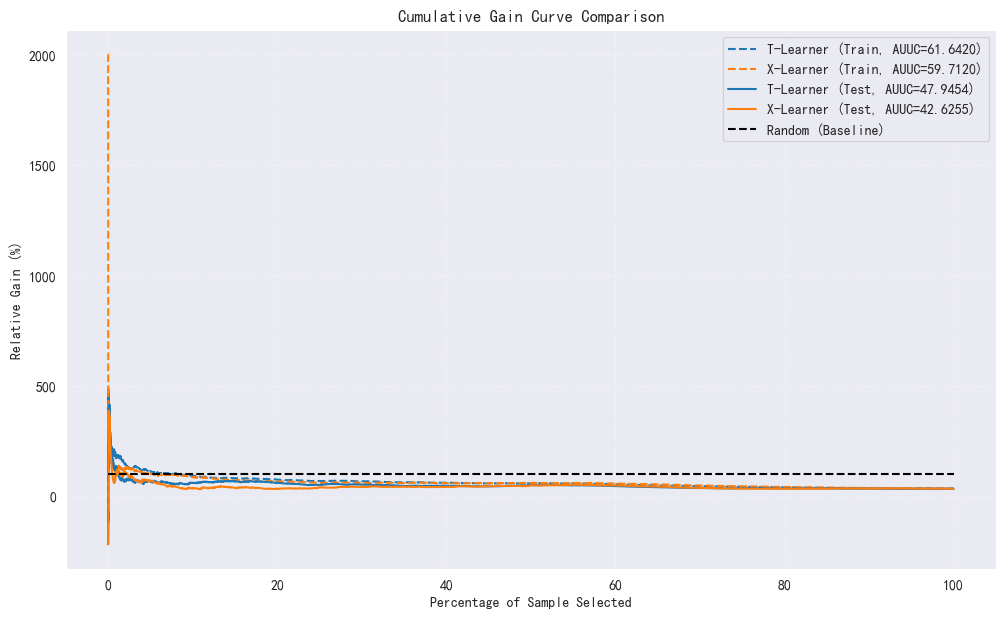

In [18]:
# 绘制增益曲线
plt.figure(figsize=(12, 7))

# 绘制训练集曲线
plt.plot(t_percentiles_train, t_gains_train, color="C0", linestyle='--', label=f'T-Learner (Train, AUUC={t_auuc_train:.4f})')
plt.plot(x_percentiles_train, x_gains_train, color="C1", linestyle='--', label=f'X-Learner (Train, AUUC={x_auuc_train:.4f})')

# 绘制测试集曲线
plt.plot(t_percentiles_test, t_gains_test, color="C0", label=f'T-Learner (Test, AUUC={t_auuc_test:.4f})')
plt.plot(x_percentiles_test, x_gains_test, color="C1", label=f'X-Learner (Test, AUUC={x_auuc_test:.4f})')

# 绘制随机选择的基准线
plt.plot([0, 100], [100, 100], linestyle="--", color="black", label="Random (Baseline)")

plt.xlabel('Percentage of Sample Selected')
plt.ylabel('Relative Gain (%)')
plt.title('Cumulative Gain Curve Comparison')
plt.legend(loc='best')
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()